# Hyperparameter Tuning & Model Optimization

## Objective

This notebook performs hyperparameter tuning for the multimodal machine learning models using the participant-level **training dataset** generated during the previous data integration stage.

Model optimization is conducted exclusively on the training partition. Hyperparameter selection is performed using stratified group cross-validation within the training set to prevent participant-level data leakage and to obtain robust estimates of model performance.

The independent validation and test datasets are intentionally excluded from the tuning process. These datasets are reserved for subsequent model selection and final performance evaluation.

## Datasets

The following participant-level training datasets are used:

- Demographics + Questionnaire
- Wearable + Questionnaire
- Full Multimodal

Each dataset contains only participants assigned to the training partition. Validation and test participants are not included during hyperparameter optimization.

## Workflow

This notebook performs the following steps:

1. Load the participant-level training datasets.
2. Build the preprocessing and feature-selection pipeline.
3. Perform hyperparameter tuning using StratifiedGroupKFold cross-validation.
4. Identify the optimal hyperparameter combination for each multimodal dataset.
5. Save the best-performing models and tuning results for downstream validation and final testing.

The independent validation and test datasets will be used in the following notebooks to assess generalization performance.

## 1. Libraries and Project Paths

In [17]:
# Libraries
from pathlib import Path
import sys
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
)

from sklearn.model_selection import (
    StratifiedGroupKFold,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [18]:
# Locate project root
cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd

elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not locate the project root containing the src directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [19]:
# Shared modeling utilities
from src.modeling import outputs
from src.modeling import tuning

from src.modeling.data_loader import (
    load_train_dataset,
    load_validation_dataset,
    load_test_dataset,
)

from src.modeling.preprocessing import (
    prepare_dataset,
)

from src.modeling.models import (
    get_logistic_regression,
    get_random_forest,
    get_xgboost,
)

from src.modeling.evaluation import (
    evaluate_model,
)

In [20]:
# Define project directories
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"

METRICS_DIR = OUTPUTS_DIR / "metrics"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for directory in [
    MODELS_DIR,
    METRICS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Metrics directory: {METRICS_DIR}")
print(f"Tables directory: {TABLES_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease
Processed data: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed
Models directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\models
Metrics directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\metrics
Tables directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables
Figures directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures


The required Python libraries, project directories, and shared modeling utilities are imported. The notebook automatically locates the project root and initializes the processed data and output directories used throughout the project.

The shared modeling modules developed during previous project stages are imported to ensure consistency across all modeling experiments. These reusable utilities provide standardized model definitions, evaluation functions, hyperparameter tuning procedures, and output management, allowing the optimization experiments performed in this notebook to follow the same implementation framework used throughout the project.

## 2. Hyperparameter Tuning Configuration

In [21]:
# Hyperparameter tuning configuration
RANDOM_STATE = 42

N_SPLITS = 5

TARGET_COLUMN = "label"
PARTICIPANT_ID_COLUMN = "patient_id"

DATASETS = {
    "Demographics + Questionnaire": {
        "train": "train_demographics_questionnaire_task_aware.csv",
        "validation": "validation_demographics_questionnaire_task_aware.csv",
        "test": "test_demographics_questionnaire_task_aware.csv",
    },
    "Wearable + Questionnaire": {
        "train": "train_wearable_questionnaire_task_aware.csv",
        "validation": "validation_wearable_questionnaire_task_aware.csv",
        "test": "test_wearable_questionnaire_task_aware.csv",
    },
    "Full Multimodal": {
        "train": "train_multimodal_full_task_aware.csv",
        "validation": "validation_multimodal_full_task_aware.csv",
        "test": "test_multimodal_full_task_aware.csv",
    },
}

MODELS = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
]

print(f"Random state: {RANDOM_STATE}")
print(f"Cross-validation folds: {N_SPLITS}")

print("\nDatasets:")
for name, files in DATASETS.items():
    print(f"\n{name}")
    print(f"  Train: {files['train']}")
    print(f"  Validation: {files['validation']}")
    print(f"  Test: {files['test']}")

print("\nModels:")
for model in MODELS:
    print(f"- {model}")

Random state: 42
Cross-validation folds: 5

Datasets:

Demographics + Questionnaire
  Train: train_demographics_questionnaire_task_aware.csv
  Validation: validation_demographics_questionnaire_task_aware.csv
  Test: test_demographics_questionnaire_task_aware.csv

Wearable + Questionnaire
  Train: train_wearable_questionnaire_task_aware.csv
  Validation: validation_wearable_questionnaire_task_aware.csv
  Test: test_wearable_questionnaire_task_aware.csv

Full Multimodal
  Train: train_multimodal_full_task_aware.csv
  Validation: validation_multimodal_full_task_aware.csv
  Test: test_multimodal_full_task_aware.csv

Models:
- Logistic Regression
- Random Forest
- XGBoost


## 3. Load Training Datasets
The participant-level training datasets generated during the task-aware data integration stage are loaded for hyperparameter optimization.

Only the training partitions are used throughout this notebook. The independent validation and test datasets remain untouched during model optimization and are reserved for subsequent model selection and final performance evaluation.

Three training datasets are included:

- Demographics + Questionnaire
- Wearable + Questionnaire
- Full Multimodal

Each dataset contains one observation per participant together with the corresponding diagnostic label. Participant identifiers are retained only to support grouped cross-validation and are excluded from model training during preprocessing.

In [22]:
# Define training datasets
dataset_paths = {
    "Demographics + Questionnaire":
        PROCESSED_DIR / "train_demographics_questionnaire_task_aware.csv",

    "Wearable + Questionnaire":
        PROCESSED_DIR / "train_wearable_questionnaire_task_aware.csv",

    "Full Multimodal":
        PROCESSED_DIR / "train_multimodal_full_task_aware.csv",
}

for dataset_name, dataset_path in dataset_paths.items():

    assert dataset_path.exists(), (
        f"Dataset not found: {dataset_path}"
    )

print("All training datasets were found.")

All training datasets were found.


In [23]:
datasets = {}

for dataset_name, dataset_path in dataset_paths.items():

    datasets[dataset_name] = pd.read_csv(
        dataset_path,
        dtype={
            PARTICIPANT_ID_COLUMN: str,
        },
    )

print("Training datasets successfully loaded.")

Training datasets successfully loaded.


In [24]:
for dataset_name, dataset in datasets.items():
    print(dataset_name)
    print("label" in dataset.columns)

Demographics + Questionnaire
True
Wearable + Questionnaire
True
Full Multimodal
True


In [25]:
dataset_summary = []

for dataset_name, dataset in datasets.items():

    dataset_summary.append({

        "Dataset":
            dataset_name,

        "Participants":
            dataset[PARTICIPANT_ID_COLUMN].nunique(),

        "Rows":
            len(dataset),

        "Columns":
            dataset.shape[1],

        "Target Classes":
            dataset[TARGET_COLUMN].nunique(),
    })

dataset_summary = pd.DataFrame(dataset_summary)

display(dataset_summary)

,Dataset,Participants,Rows,Columns,Target Classes
0,Demographics + Questionnaire,328,328,59,3
1,Wearable + Questionnaire,328,328,2403,3
2,Full Multimodal,328,328,2413,3


In [26]:
for dataset_name, dataset in datasets.items():

    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    display(dataset.head())

Demographics + Questionnaire


,patient_id,study_id,condition_original,condition_group,label,age,height_cm,weight_kg,gender,handedness,...,gastrointestinal_count,urinal_count,pain_count,miscellaneous_count,apathy_attention_memory_count,distortion_perception_count,depression_anxiety_count,sexual_function_count,cardiovascular_count,sleep_fatigue_count
0,1,PADS,Healthy,Healthy Control,0,56.0,173.0,78.0,Male,Right,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,PADS,Other Movement Disorders,Other Movement Disorder,2,81.0,193.0,104.0,Male,Right,...,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,3.0
2,5,PADS,Parkinson's,Parkinson's Disease,1,75.0,172.0,86.0,Male,Left,...,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,5.0
3,6,PADS,Parkinson's,Parkinson's Disease,1,72.0,171.0,115.0,Female,Right,...,2.0,2.0,0.0,2.0,3.0,2.0,1.0,0.0,2.0,2.0
4,7,PADS,Other Movement Disorders,Other Movement Disorder,2,74.0,181.0,94.0,Male,Right,...,5.0,2.0,0.0,1.0,0.0,1.0,0.0,2.0,3.0,2.0


Wearable + Questionnaire


,patient_id,CrossArms_Left_AccX_Mean,CrossArms_Right_AccX_Mean,DrinkGlas_Left_AccX_Mean,DrinkGlas_Right_AccX_Mean,Entrainment_Left_AccX_Mean,Entrainment_Right_AccX_Mean,HoldWeight_Left_AccX_Mean,HoldWeight_Right_AccX_Mean,LiftHold_Left_AccX_Mean,...,miscellaneous_count,apathy_attention_memory_count,distortion_perception_count,depression_anxiety_count,sexual_function_count,cardiovascular_count,sleep_fatigue_count,condition_original,condition_group,label
0,1,-0.000278,0.000139,0.000321,0.000390,0.000133,-0.000149,0.000143,0.000059,-0.000554,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Healthy,Healthy Control,0
1,2,-0.000024,-0.000415,0.003220,0.000288,-0.000354,-0.000638,0.000185,-0.000127,-0.000429,...,1.0,0.0,1.0,1.0,0.0,3.0,3.0,Other Movement Disorders,Other Movement Disorder,2
2,5,-0.000261,-0.001369,-0.000220,-0.002176,0.000140,-0.000013,-0.000131,0.000340,0.000419,...,0.0,0.0,1.0,0.0,0.0,2.0,5.0,Parkinson's,Parkinson's Disease,1
3,6,-0.000444,0.000897,-0.000109,0.000677,0.000042,-0.000670,0.000172,0.000294,0.000381,...,2.0,3.0,2.0,1.0,0.0,2.0,2.0,Parkinson's,Parkinson's Disease,1
4,7,-0.001024,0.000948,0.000103,-0.000572,0.000095,0.000167,-0.000031,-0.000305,-0.000202,...,1.0,0.0,1.0,0.0,2.0,3.0,2.0,Other Movement Disorders,Other Movement Disorder,2


Full Multimodal


,patient_id,CrossArms_Left_AccX_Mean,CrossArms_Right_AccX_Mean,DrinkGlas_Left_AccX_Mean,DrinkGlas_Right_AccX_Mean,Entrainment_Left_AccX_Mean,Entrainment_Right_AccX_Mean,HoldWeight_Left_AccX_Mean,HoldWeight_Right_AccX_Mean,LiftHold_Left_AccX_Mean,...,study_id,age,height_cm,weight_kg,gender,handedness,family_history_any,family_history_first_degree,alcohol_effect_on_tremor,duplicate_patient_id
0,1,-0.000278,0.000139,0.000321,0.000390,0.000133,-0.000149,0.000143,0.000059,-0.000554,...,PADS,56.0,173.0,78.0,Male,Right,Yes,Yes,Unknown,False
1,2,-0.000024,-0.000415,0.003220,0.000288,-0.000354,-0.000638,0.000185,-0.000127,-0.000429,...,PADS,81.0,193.0,104.0,Male,Right,No,Unknown,No Effect,False
2,5,-0.000261,-0.001369,-0.000220,-0.002176,0.000140,-0.000013,-0.000131,0.000340,0.000419,...,PADS,75.0,172.0,86.0,Male,Left,No,Unknown,Unknown,False
3,6,-0.000444,0.000897,-0.000109,0.000677,0.000042,-0.000670,0.000172,0.000294,0.000381,...,PADS,72.0,171.0,115.0,Female,Right,No,No,Unknown,False
4,7,-0.001024,0.000948,0.000103,-0.000572,0.000095,0.000167,-0.000031,-0.000305,-0.000202,...,PADS,74.0,181.0,94.0,Male,Right,No,Unknown,No Effect,False


The participant-level training datasets generated during the task-aware data integration stage were successfully loaded. Three training datasets were included in the hyperparameter optimization process: the demographics plus questionnaire dataset, the wearable plus questionnaire dataset, and the full multimodal dataset.

Each dataset contains one observation per participant together with the corresponding diagnostic label. The participant identifier is retained only to support grouped cross-validation and is excluded from model training during preprocessing. A preliminary inspection of the training datasets was performed to verify their dimensions, participant counts, and overall structure before hyperparameter optimization.

## 4. Dataset Validation

In [27]:
# Validate participant-level training datasets
validation_summary = []
for dataset_name, dataset in datasets.items():
    required_columns = {
        PARTICIPANT_ID_COLUMN,
        TARGET_COLUMN,
    }

    missing_columns = required_columns.difference(
        dataset.columns
    )

    assert not missing_columns, (
        f"{dataset_name}: Missing required columns: "
        f"{sorted(missing_columns)}"
    )

    assert dataset[
        PARTICIPANT_ID_COLUMN
    ].notna().all(), (
        f"{dataset_name}: Missing participant identifiers."
    )

    duplicate_participants = dataset[
        dataset[PARTICIPANT_ID_COLUMN]
        .duplicated(keep=False)
    ]

    assert duplicate_participants.empty, (
        f"{dataset_name}: Duplicate participant rows detected."
    )

    assert dataset[TARGET_COLUMN].notna().all(), (
        f"{dataset_name}: Missing target labels."
    )

    validation_summary.append({

        "Dataset":
            dataset_name,

        "Participants":
            dataset[PARTICIPANT_ID_COLUMN].nunique(),

        "Rows":
            len(dataset),

        "Duplicate Participants":
            duplicate_participants.shape[0],

        "Missing Labels":
            dataset[TARGET_COLUMN].isna().sum(),

        "Validation":
            "PASS",
    })

validation_summary = pd.DataFrame(validation_summary)

display(validation_summary)

,Dataset,Participants,Rows,Duplicate Participants,Missing Labels,Validation
0,Demographics + Questionnaire,328,328,0,0,PASS
1,Wearable + Questionnaire,328,328,0,0,PASS
2,Full Multimodal,328,328,0,0,PASS


The participant-level training datasets were validated before hyperparameter optimization. Each dataset was examined to verify the presence of the required participant identifier and target label, ensure participant uniqueness, and confirm that no missing diagnostic labels were present.

Class distributions were also reviewed to verify consistency across the three training datasets before grouped cross-validation and hyperparameter tuning. These validation checks help ensure that all training datasets satisfy the assumptions required for reproducible participant-level model optimization while preserving the independent validation and test datasets for subsequent evaluation.

## 5. Build Leakage-Safe Modeling Pipeline
The participant-level training datasets were prepared for hyperparameter optimization using the shared preprocessing utilities developed during the Week 4 modeling framework.

For each dataset, predictor variables were separated from the target labels while participant identifiers were retained exclusively to define the grouped cross-validation strategy. Shared preprocessing pipelines were constructed automatically for each dataset to ensure consistent feature engineering across all multimodal experiments.

In [28]:
# Prepare datasets for hyperparameter tuning
prepared_datasets = {}

for dataset_name, dataset in datasets.items():

    X, y, preprocessing = prepare_dataset(
        dataset,
    )

    prepared_datasets[dataset_name] = {

        "X": X,

        "y": y,

        "groups": dataset[
            PARTICIPANT_ID_COLUMN
        ],

        "preprocessing": preprocessing,

    }

print("Training datasets prepared successfully.")

Training datasets prepared successfully.


In [29]:
# Verify prepared datasets
prepared_summary = []

for dataset_name, data in prepared_datasets.items():

    prepared_summary.append({

        "Dataset":
            dataset_name,

        "Samples":
            data["X"].shape[0],

        "Features":
            data["X"].shape[1],

        "Classes":
            data["y"].nunique(),

    })

prepared_summary = pd.DataFrame(
    prepared_summary,
)

display(prepared_summary)

,Dataset,Samples,Features,Classes
0,Demographics + Questionnaire,328,52,3
1,Wearable + Questionnaire,328,2398,3
2,Full Multimodal,328,2406,3


In [30]:
# Build grouped cross-validation strategy
cv = StratifiedGroupKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=RANDOM_STATE,

)

print(cv)

StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True)


Each training dataset was prepared using the shared preprocessing framework to ensure consistent feature engineering across all multimodal experiments.

Predictor variables, target labels, participant identifiers, and preprocessing pipelines were stored for each dataset before model optimization. Participant identifiers are used exclusively to define the grouped cross-validation strategy and are never included as predictor variables.

During hyperparameter optimization, preprocessing, variance filtering, feature selection, and model fitting are performed entirely within each training fold, preventing participant-level data leakage while preserving reproducibility across all experiments.

## 6. Hyperparameter Tuning
Hyperparameter optimization was performed independently for each training dataset and model family using the shared preprocessing framework and grouped cross-validation.

For every experiment, preprocessing, variance filtering, feature selection, and classifier training were jointly optimized using GridSearchCV. The complete preprocessing pipeline was fitted exclusively within each training fold, while participant identifiers were used only to define the grouped cross-validation strategy.

The optimal hyperparameter combination was selected according to the highest mean cross-validation macro F1 score. The resulting tuned models were retained for subsequent validation and final testing.

In [31]:
# Initialize tuning results
tuning_results = []
best_models = {}
cv_results_tables = {}
print("Hyperparameter tuning initialized.")

Hyperparameter tuning initialized.


In [32]:
# Tune all datasets and models
for dataset_name, data in prepared_datasets.items():

    print("=" * 80)
    print(f"Dataset: {dataset_name}")
    print("=" * 80)

    X = data["X"]
    y = data["y"]
    groups = data["groups"]
    preprocessing = data["preprocessing"]

    model_names = {
        "Logistic Regression": "logistic_regression",
        "Random Forest": "random_forest",
        "XGBoost": "xgboost",
    }

    for display_name, model_key in model_names.items():

        print(f"\nTuning {display_name}...")

        model, param_grid = tuning.get_model_and_grid(
            model_key,
            X.shape[1],
        )

        pipeline = Pipeline(
            steps=[
                (
                    "preprocessing",
                    preprocessing,
                ),
                (
                    "variance_filter",
                    VarianceThreshold(
                        threshold=0.0,
                    ),
                ),
                (
                    "feature_selection",
                    SelectKBest(
                        score_func=f_classif,
                        k="all",
                    ),
                ),
                (
                    "classifier",
                    model,
                ),
            ]
        )

        start_time = time.perf_counter()

        (
            best_model,
            best_parameters,
            best_metrics,
            cv_results,
        ) = tuning.tune_model(
            pipeline=pipeline,
            param_grid=param_grid,
            X=X,
            y=y,
            groups=groups,
            cv=cv,
        )

        training_time = (
            time.perf_counter()
            - start_time
        )

        best_models[
            (dataset_name, display_name)
        ] = best_model

        cv_results_tables[
            (dataset_name, display_name)
        ] = cv_results

        tuning_results.append({

            "Dataset":
                dataset_name,

            "Model":
                display_name,

            "Macro F1":
                best_metrics["macro_f1"],

            "Balanced Accuracy":
                best_metrics["balanced_accuracy"],

            "Accuracy":
                best_metrics["accuracy"],

            "Precision Macro":
                best_metrics["precision_macro"],

            "Recall Macro":
                best_metrics["recall_macro"],

            "Training Time (s)":
                training_time,

            "Best Parameters":
                best_parameters,

        })

        print(
            f"Best Macro F1: "
            f"{best_metrics['macro_f1']:.4f}"
        )

        print(
            f"Balanced Accuracy: "
            f"{best_metrics['balanced_accuracy']:.4f}"
        )

Dataset: Demographics + Questionnaire

Tuning Logistic Regression...


Best Macro F1: 0.6089
Balanced Accuracy: 0.6578

Tuning Random Forest...
Best Macro F1: 0.6199
Balanced Accuracy: 0.6440

Tuning XGBoost...
Best Macro F1: 0.5982
Balanced Accuracy: 0.5929
Dataset: Wearable + Questionnaire

Tuning Logistic Regression...
Best Macro F1: 0.6875
Balanced Accuracy: 0.6890

Tuning Random Forest...
Best Macro F1: 0.6834
Balanced Accuracy: 0.6840

Tuning XGBoost...
Best Macro F1: 0.6844
Balanced Accuracy: 0.6672
Dataset: Full Multimodal

Tuning Logistic Regression...
Best Macro F1: 0.6857
Balanced Accuracy: 0.6892

Tuning Random Forest...
Best Macro F1: 0.6863
Balanced Accuracy: 0.6933

Tuning XGBoost...
Best Macro F1: 0.6762
Balanced Accuracy: 0.6597


In [33]:
# Tuning summary
tuning_summary = pd.DataFrame(
    tuning_results,
)

display(
    tuning_summary
)

,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters
0,Demographics + Questionnaire,Logistic Regression,0.608928,0.657845,0.655571,0.606712,0.657845,27.903671,"{'classifier__C': 0.1, 'classifier__max_iter':..."
1,Demographics + Questionnaire,Random Forest,0.619851,0.643992,0.698322,0.636911,0.643992,1507.516596,"{'classifier__max_depth': None, 'classifier__m..."
2,Demographics + Questionnaire,XGBoost,0.598170,0.592890,0.692214,0.645921,0.592890,222.591484,"{'classifier__colsample_bytree': 1.0, 'classif..."
3,Wearable + Questionnaire,Logistic Regression,0.687465,0.689042,0.743776,0.695821,0.689042,102.895731,"{'classifier__C': 1, 'classifier__max_iter': 1..."
4,Wearable + Questionnaire,Random Forest,0.683423,0.684023,0.737669,0.691162,0.684023,7339.940151,"{'classifier__max_depth': None, 'classifier__m..."
5,Wearable + Questionnaire,XGBoost,0.684395,0.667196,0.762005,0.755484,0.667196,46294.753700,"{'classifier__colsample_bytree': 0.8, 'classif..."
6,Full Multimodal,Logistic Regression,0.685731,0.689227,0.740746,0.694050,0.689227,103.903555,"{'classifier__C': 1, 'classifier__max_iter': 1..."
7,Full Multimodal,Random Forest,0.686305,0.693289,0.737762,0.688910,0.693289,7850.438869,"{'classifier__max_depth': None, 'classifier__m..."
8,Full Multimodal,XGBoost,0.676227,0.659684,0.765035,0.767604,0.659684,19850.267780,"{'classifier__colsample_bytree': 1.0, 'classif..."


In [34]:
# Save tuning summary
outputs.save_table(
    tuning_summary,
    "hyperparameter_tuning_summary.csv",
)

print(
    "Hyperparameter tuning completed and summary saved."
)

Hyperparameter tuning completed and summary saved.


## 7. Cross-Validation Results
Hyperparameter optimization was performed using five-fold grouped stratified cross-validation on the participant-level training datasets. Macro F1-score was adopted as the primary optimization metric because it provides a balanced assessment of multiclass classification performance under class imbalance. Balanced Accuracy, Overall Accuracy, Precision Macro, and Recall Macro were additionally reported to provide complementary measures of predictive performance.

The following analysis summarizes the cross-validation performance of the optimal hyperparameter configuration identified for each dataset-model combination. These results correspond exclusively to the training data and were obtained before evaluation on the independent validation and test datasets.

In [35]:
# Cross-validation performance summary
cross_validation_summary = tuning_summary.copy()
cross_validation_summary = (
    cross_validation_summary
    .sort_values(
        by=[
            "Macro F1",
            "Balanced Accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)
cross_validation_summary.insert(
    0,
    "Rank",
    range(
        1,
        len(cross_validation_summary) + 1,
    ),
)
display(cross_validation_summary)

,Rank,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters
0,1,Wearable + Questionnaire,Logistic Regression,0.687465,0.689042,0.743776,0.695821,0.689042,102.895731,"{'classifier__C': 1, 'classifier__max_iter': 1..."
1,2,Full Multimodal,Random Forest,0.686305,0.693289,0.737762,0.688910,0.693289,7850.438869,"{'classifier__max_depth': None, 'classifier__m..."
2,3,Full Multimodal,Logistic Regression,0.685731,0.689227,0.740746,0.694050,0.689227,103.903555,"{'classifier__C': 1, 'classifier__max_iter': 1..."
3,4,Wearable + Questionnaire,XGBoost,0.684395,0.667196,0.762005,0.755484,0.667196,46294.753700,"{'classifier__colsample_bytree': 0.8, 'classif..."
4,5,Wearable + Questionnaire,Random Forest,0.683423,0.684023,0.737669,0.691162,0.684023,7339.940151,"{'classifier__max_depth': None, 'classifier__m..."
5,6,Full Multimodal,XGBoost,0.676227,0.659684,0.765035,0.767604,0.659684,19850.267780,"{'classifier__colsample_bytree': 1.0, 'classif..."
6,7,Demographics + Questionnaire,Random Forest,0.619851,0.643992,0.698322,0.636911,0.643992,1507.516596,"{'classifier__max_depth': None, 'classifier__m..."
7,8,Demographics + Questionnaire,Logistic Regression,0.608928,0.657845,0.655571,0.606712,0.657845,27.903671,"{'classifier__C': 0.1, 'classifier__max_iter':..."
8,9,Demographics + Questionnaire,XGBoost,0.598170,0.592890,0.692214,0.645921,0.592890,222.591484,"{'classifier__colsample_bytree': 1.0, 'classif..."


In [36]:
# Save cross-validation summary
outputs.save_table(
    cross_validation_summary,
    "cross_validation_summary.csv",
)
print("Cross-validation summary saved.")

Cross-validation summary saved.


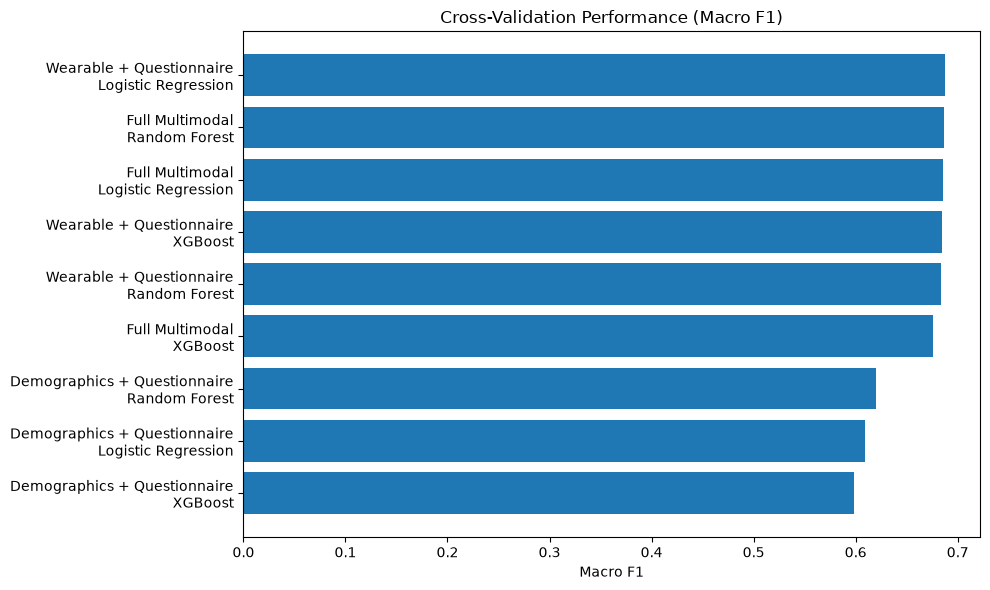

In [37]:
# Figure - Cross-validation Macro F1
plot_data = cross_validation_summary.sort_values(
    "Macro F1",
    ascending=True,
)
fig, ax = plt.subplots(
    figsize=(10,6)
)
labels = (
    plot_data["Dataset"]
    + "\n"
    + plot_data["Model"]
)
ax.barh(
    labels,
    plot_data["Macro F1"],
)
ax.set_xlabel(
    "Macro F1"
)
ax.set_title(
    "Cross-Validation Performance (Macro F1)"
)
plt.tight_layout()
outputs.save_figure(
    fig,
    "11b_cross_validation_macro_f1.png",
)
plt.show()

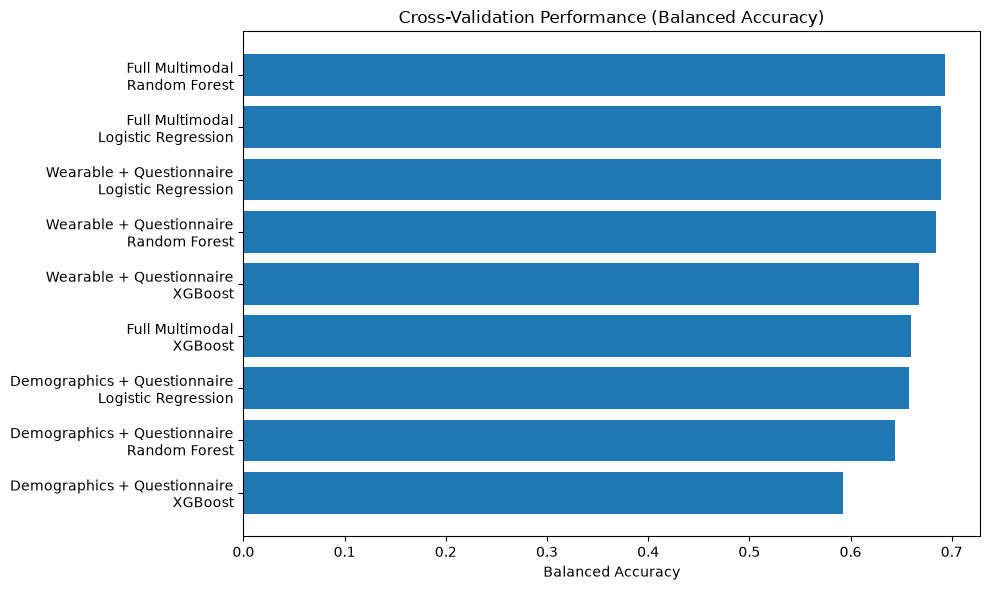

In [38]:
# Figure - Cross-validation Balanced Accuracy
plot_data = cross_validation_summary.sort_values(
    "Balanced Accuracy",
    ascending=True,
)
fig, ax = plt.subplots(
    figsize=(10,6)
)
labels = (
    plot_data["Dataset"]
    + "\n"
    + plot_data["Model"]
)
ax.barh(
    labels,
    plot_data["Balanced Accuracy"],
)
ax.set_xlabel(
    "Balanced Accuracy"
)
ax.set_title(
    "Cross-Validation Performance (Balanced Accuracy)"
)
plt.tight_layout()
outputs.save_figure(
    fig,
    "11b_cross_validation_balanced_accuracy.png",
)
plt.show()

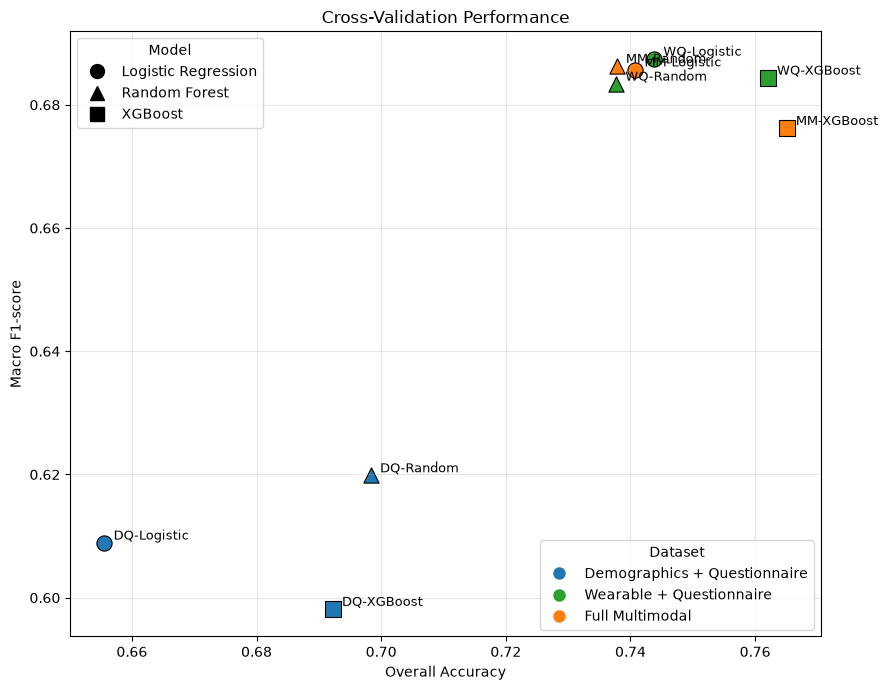

In [40]:
# Figure - Macro F1 vs Accuracy
fig, ax = plt.subplots(
    figsize=(9, 7)
)
dataset_colors = {
    "Demographics + Questionnaire": "#1f77b4",
    "Wearable + Questionnaire": "#2ca02c",
    "Full Multimodal": "#ff7f0e",
}
model_markers = {
    "Logistic Regression": "o",
    "Random Forest": "^",
    "XGBoost": "s",
}
dataset_short = {
    "Demographics + Questionnaire": "DQ",
    "Wearable + Questionnaire": "WQ",
    "Full Multimodal": "MM",
}
for _, row in cross_validation_summary.iterrows():
    ax.scatter(

        row["Accuracy"],

        row["Macro F1"],

        color=dataset_colors[row["Dataset"]],

        marker=model_markers[row["Model"]],

        s=120,

        edgecolor="black",

        linewidth=0.8,

    )

    ax.text(

        row["Accuracy"] + 0.0015,

        row["Macro F1"] + 0.0005,

        f"{dataset_short[row['Dataset']]}-{row['Model'].split()[0]}",

        fontsize=9,

    )

# Legend for datasets
dataset_handles = [

    plt.Line2D(

        [0],

        [0],

        marker="o",

        color="w",

        markerfacecolor=color,

        markersize=10,

        label=name,

    )

    for name, color in dataset_colors.items()

]

# Legend for models
model_handles = [

    plt.Line2D(

        [0],

        [0],

        marker=marker,

        color="black",

        linestyle="",

        markersize=10,

        label=name,

    )

    for name, marker in model_markers.items()

]

legend1 = ax.legend(

    handles=dataset_handles,

    title="Dataset",

    loc="lower right",

)

ax.add_artist(legend1)

ax.legend(

    handles=model_handles,

    title="Model",

    loc="upper left",

)

ax.set_xlabel("Overall Accuracy")

ax.set_ylabel("Macro F1-score")

ax.set_title("Cross-Validation Performance")

ax.grid(
    alpha=0.3,
)

plt.tight_layout()
outputs.save_figure(
    fig,
    "11b_macro_f1_vs_accuracy.png",
)
plt.show()

The grouped cross-validation results indicate the relative performance of each model across the three multimodal datasets during hyperparameter optimization. Because all preprocessing, feature selection, and model fitting were performed independently within each grouped cross-validation fold, these estimates provide an unbiased assessment of model performance on the training data while preventing participant-level data leakage.

The highest-performing model from each dataset was retained for subsequent evaluation on the independent validation dataset before final assessment on the held-out test dataset.

## 8. Model Stability Analysis
Model selection should not rely solely on average predictive performance. Therefore, the stability of each tuned model was evaluated using the grouped cross-validation results obtained from the optimal hyperparameter configuration.

For each model, the mean Macro F1-score, standard deviation, minimum fold performance, maximum fold performance, and coefficient of variation were calculated. These statistics provide insight into the consistency and robustness of each classifier across the grouped validation folds.

In [41]:
# Model stability analysis
stability_summary = []
for (dataset, model), cv_results in cv_results_tables.items():
    best_index = cv_results[
        "mean_test_macro_f1"
    ].idxmax()
    fold_scores = [
        cv_results.loc[
            best_index,
            f"split{i}_test_macro_f1",
        ]
        for i in range(N_SPLITS)
    ]
    mean_macro_f1 = cv_results.loc[
        best_index,
        "mean_test_macro_f1",
    ]
    std_macro_f1 = cv_results.loc[
        best_index,
        "std_test_macro_f1",
    ]
    stability_summary.append({
        "Dataset":
            dataset,

        "Model":
            model,

        "Macro F1":
            mean_macro_f1,

        "Standard Deviation":
            std_macro_f1,

        "Minimum Fold":
            np.min(fold_scores),

        "Maximum Fold":
            np.max(fold_scores),

        "Coefficient of Variation (%)":
            (
                std_macro_f1
                / mean_macro_f1
            )
            * 100,

    })

stability_summary = pd.DataFrame(
    stability_summary,
)

stability_summary = (
    stability_summary
    .sort_values(
        "Macro F1",
        ascending=False,
    )
)

display(stability_summary)

,Dataset,Model,Macro F1,Standard Deviation,Minimum Fold,Maximum Fold,Coefficient of Variation (%)
3,Wearable + Questionnaire,Logistic Regression,0.687465,0.070230,0.621951,0.820714,10.215746
7,Full Multimodal,Random Forest,0.686305,0.056373,0.602183,0.751587,8.213921
6,Full Multimodal,Logistic Regression,0.685731,0.065021,0.621951,0.808658,9.482007
5,Wearable + Questionnaire,XGBoost,0.684395,0.050233,0.601401,0.737929,7.339758
4,Wearable + Questionnaire,Random Forest,0.683423,0.051214,0.601396,0.743592,7.493693
8,Full Multimodal,XGBoost,0.676227,0.045293,0.601401,0.732483,6.697960
1,Demographics + Questionnaire,Random Forest,0.619851,0.059567,0.560212,0.693823,9.609972
0,Demographics + Questionnaire,Logistic Regression,0.608928,0.040426,0.537245,0.660094,6.638864
2,Demographics + Questionnaire,XGBoost,0.598170,0.058809,0.489103,0.650628,9.831443


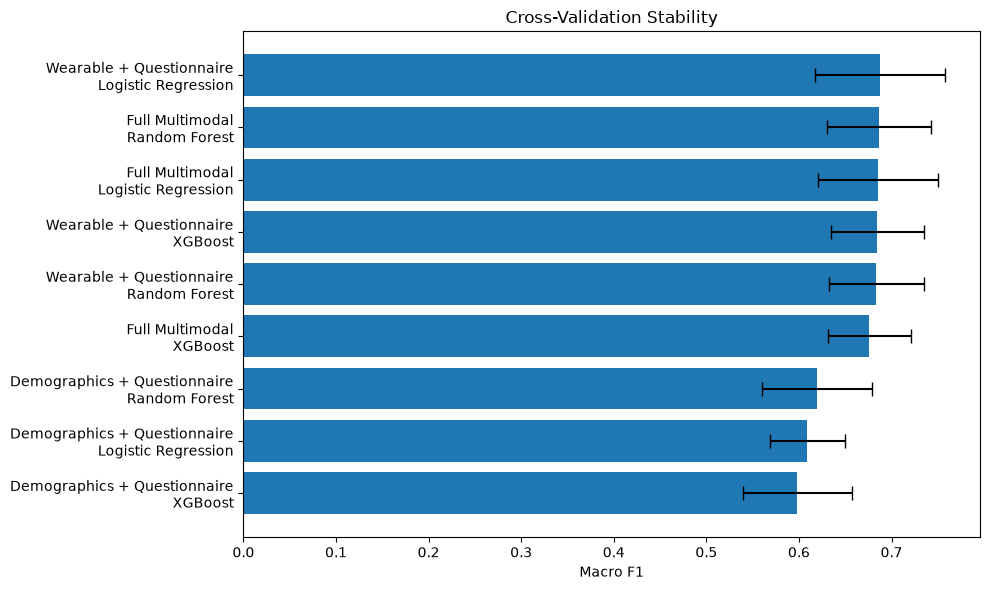

In [42]:
# Cross-validation stability
plot_data = stability_summary.sort_values(
    "Macro F1",
    ascending=True,
)
fig, ax = plt.subplots(
    figsize=(10,6)
)
labels = (
    plot_data["Dataset"]
    + "\n"
    + plot_data["Model"]
)
ax.barh(
    labels,
    plot_data["Macro F1"],
    xerr=plot_data["Standard Deviation"],
    capsize=5,
)
ax.set_xlabel(
    "Macro F1"
)
ax.set_title(
    "Cross-Validation Stability"
)
plt.tight_layout()
outputs.save_figure(
    fig,
    "cross_validation_stability.png",
)
plt.show()

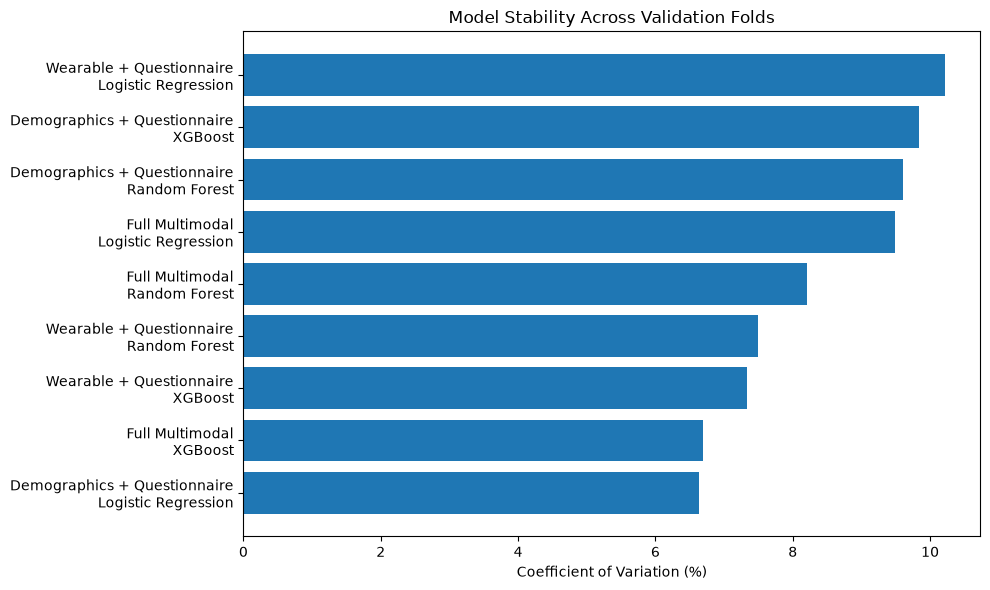

In [43]:
# Coefficient of variation
plot_data = stability_summary.sort_values(
    "Coefficient of Variation (%)"
)

fig, ax = plt.subplots(
    figsize=(10,6)
)

labels = (

    plot_data["Dataset"]

    + "\n"

    + plot_data["Model"]

)

ax.barh(

    labels,

    plot_data["Coefficient of Variation (%)"],

)

ax.set_xlabel(
    "Coefficient of Variation (%)"
)

ax.set_title(
    "Model Stability Across Validation Folds"
)

plt.tight_layout()

outputs.save_figure(
    fig,
    "model_stability_coefficient_variation.png",
)

plt.show()

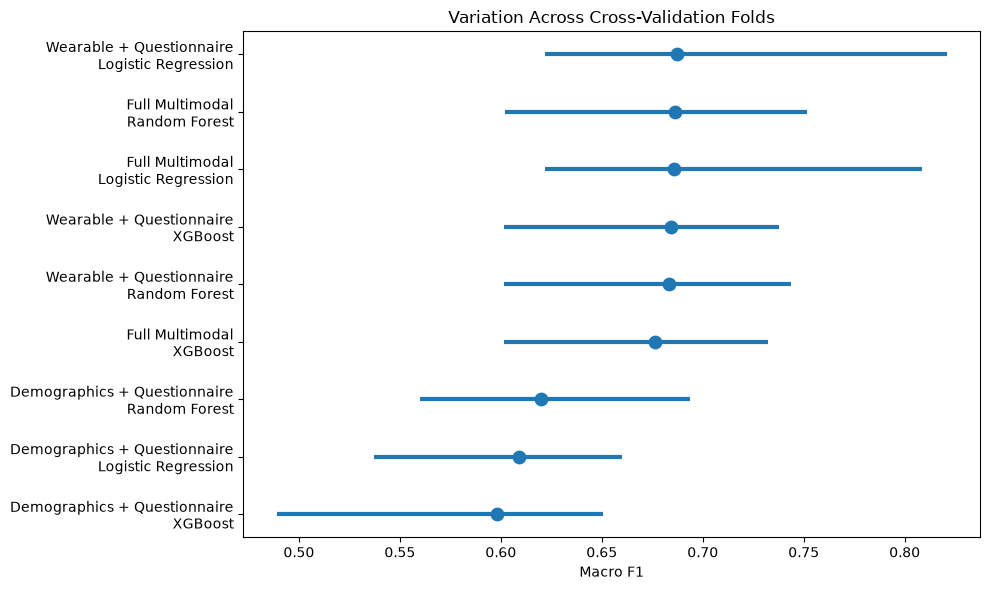

In [44]:
# Fold performance range
plot_data = stability_summary.sort_values(
    "Macro F1"
)
fig, ax = plt.subplots(
    figsize=(10,6)
)

y = np.arange(len(plot_data))

ax.hlines(

    y,

    plot_data["Minimum Fold"],

    plot_data["Maximum Fold"],

    linewidth=3,

)

ax.scatter(

    plot_data["Macro F1"],

    y,

    s=80,

)

ax.set_yticks(y)

ax.set_yticklabels(

    plot_data["Dataset"]

    + "\n"

    + plot_data["Model"]

)

ax.set_xlabel(
    "Macro F1"
)

ax.set_title(
    "Variation Across Cross-Validation Folds"
)
plt.tight_layout()

outputs.save_figure(
    fig,
    "cross_validation_fold_range.png",
)

plt.show()

In [45]:
# Save stability summary
outputs.save_table(
    stability_summary,
    "model_stability_summary.csv",
)
print("Model stability summary saved.")

Model stability summary saved.


The stability analysis complements the average cross-validation performance by quantifying the variability of each tuned model across the grouped validation folds. Models exhibiting higher Macro F1-scores together with lower standard deviations and coefficients of variation demonstrate greater robustness and more consistent predictive performance.

These stability estimates were computed exclusively from the grouped cross-validation performed on the training datasets and were used to support model selection prior to evaluation on the independent validation dataset.

## 9. Computational Performance

In addition to predictive performance, the computational efficiency of each tuned model was evaluated using the participant-level training datasets. Two complementary metrics were considered: inference time and serialized model size.

Inference time was measured as the elapsed time required to generate predictions for the complete training dataset, whereas model size was estimated from the serialized model object. These metrics provide additional insight into the computational requirements of each classifier and facilitate comparison between predictive performance and deployment cost.

In [46]:
# Measure inference time and model size
import pickle
import time
computational_metrics = []
for (dataset_name, model_name), model in best_models.items():
    X = prepared_datasets[dataset_name]["X"]
    # Inference time
    start = time.perf_counter()
    _ = model.predict(X)
    inference_time = (
        time.perf_counter()
        - start
    )
    # Serialized model size
    model_bytes = pickle.dumps(model)
    model_size_kb = (
        len(model_bytes)
        / 1024
    )
    computational_metrics.append({
        "Dataset":
            dataset_name,
        "Model":
            model_name,
        "Inference Time (s)":
            inference_time,
        "Model Size (KB)":
            model_size_kb,
    })

computational_metrics = pd.DataFrame(
    computational_metrics,
)
display(computational_metrics)

,Dataset,Model,Inference Time (s),Model Size (KB)
0,Demographics + Questionnaire,Logistic Regression,0.038431,8.420898
1,Demographics + Questionnaire,Random Forest,0.101763,706.986328
2,Demographics + Questionnaire,XGBoost,0.060958,647.409180
3,Wearable + Questionnaire,Logistic Regression,0.279736,268.840820
4,Wearable + Questionnaire,Random Forest,0.238205,2670.425781
5,Wearable + Questionnaire,XGBoost,0.900451,836.027344
6,Full Multimodal,Logistic Regression,0.278383,269.896484
7,Full Multimodal,Random Forest,0.236057,1780.513672
8,Full Multimodal,XGBoost,0.172930,835.943359


In [47]:
computational_summary = tuning_summary.merge(
    computational_metrics,
    on=[
        "Dataset",
        "Model",
    ],
    how="left",
)
display(computational_summary)

,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters,Inference Time (s),Model Size (KB)
0,Demographics + Questionnaire,Logistic Regression,0.608928,0.657845,0.655571,0.606712,0.657845,27.903671,"{'classifier__C': 0.1, 'classifier__max_iter':...",0.038431,8.420898
1,Demographics + Questionnaire,Random Forest,0.619851,0.643992,0.698322,0.636911,0.643992,1507.516596,"{'classifier__max_depth': None, 'classifier__m...",0.101763,706.986328
2,Demographics + Questionnaire,XGBoost,0.598170,0.592890,0.692214,0.645921,0.592890,222.591484,"{'classifier__colsample_bytree': 1.0, 'classif...",0.060958,647.409180
3,Wearable + Questionnaire,Logistic Regression,0.687465,0.689042,0.743776,0.695821,0.689042,102.895731,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.279736,268.840820
4,Wearable + Questionnaire,Random Forest,0.683423,0.684023,0.737669,0.691162,0.684023,7339.940151,"{'classifier__max_depth': None, 'classifier__m...",0.238205,2670.425781
5,Wearable + Questionnaire,XGBoost,0.684395,0.667196,0.762005,0.755484,0.667196,46294.753700,"{'classifier__colsample_bytree': 0.8, 'classif...",0.900451,836.027344
6,Full Multimodal,Logistic Regression,0.685731,0.689227,0.740746,0.694050,0.689227,103.903555,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.278383,269.896484
7,Full Multimodal,Random Forest,0.686305,0.693289,0.737762,0.688910,0.693289,7850.438869,"{'classifier__max_depth': None, 'classifier__m...",0.236057,1780.513672
8,Full Multimodal,XGBoost,0.676227,0.659684,0.765035,0.767604,0.659684,19850.267780,"{'classifier__colsample_bytree': 1.0, 'classif...",0.172930,835.943359


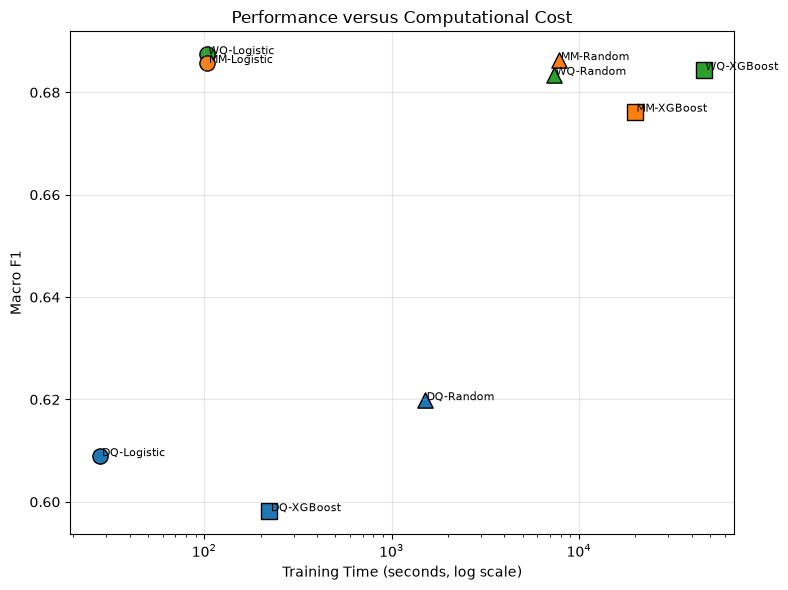

In [49]:
# Performance vs computational cost
fig, ax = plt.subplots(
    figsize=(8,6)
)

dataset_colors = {
    "Demographics + Questionnaire": "#1f77b4",
    "Wearable + Questionnaire": "#2ca02c",
    "Full Multimodal": "#ff7f0e",
}

model_markers = {
    "Logistic Regression": "o",
    "Random Forest": "^",
    "XGBoost": "s",
}

dataset_short = {
    "Demographics + Questionnaire": "DQ",
    "Wearable + Questionnaire": "WQ",
    "Full Multimodal": "MM",
}

for _, row in computational_summary.iterrows():

    ax.scatter(

        row["Training Time (s)"],

        row["Macro F1"],

        color=dataset_colors[row["Dataset"]],

        marker=model_markers[row["Model"]],

        s=120,

        edgecolor="black",

    )

    ax.text(

        row["Training Time (s)"] * 1.02,

        row["Macro F1"],

        f"{dataset_short[row['Dataset']]}-{row['Model'].split()[0]}",

        fontsize=8,

    )

ax.set_xscale("log")

ax.set_xlabel(
    "Training Time (seconds, log scale)"
)

ax.set_ylabel(
    "Macro F1"
)

ax.set_title(
    "Performance versus Computational Cost"
)

ax.grid(alpha=0.3)

plt.tight_layout()

outputs.save_figure(
    fig,
    "11b_performance_vs_training_time.png",
)

plt.show()

The computational analysis complements the predictive evaluation by quantifying the inference cost and storage requirements of each optimized classifier. Together with the cross-validation metrics, these results facilitate a balanced comparison between predictive accuracy and computational efficiency.

These measurements were obtained from the tuned models trained on the participant-level training datasets and serve as an additional criterion for selecting candidate models for subsequent validation.

## 10. Candidate Models for Validation
The grouped cross-validation results were used to identify candidate models for subsequent evaluation on the independent validation dataset.

Rather than selecting a final classifier solely based on cross-validation performance, the best-performing models from each dataset were retained for validation. This approach preserves the validation dataset as an independent source of evidence before final model selection and evaluation on the held-out test dataset.

In [50]:
# Candidate models for validation
candidate_models = computational_summary.merge(
    stability_summary[
        [
            "Dataset",
            "Model",
            "Standard Deviation",
            "Coefficient of Variation (%)",
        ]
    ],
    on=[
        "Dataset",
        "Model",
    ],
)
candidate_models = candidate_models.sort_values(
    by=[
        "Macro F1",
        "Balanced Accuracy",
    ],
    ascending=False,
)
display(candidate_models)

,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters,Inference Time (s),Model Size (KB),Standard Deviation,Coefficient of Variation (%)
3,Wearable + Questionnaire,Logistic Regression,0.687465,0.689042,0.743776,0.695821,0.689042,102.895731,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.279736,268.840820,0.070230,10.215746
7,Full Multimodal,Random Forest,0.686305,0.693289,0.737762,0.688910,0.693289,7850.438869,"{'classifier__max_depth': None, 'classifier__m...",0.236057,1780.513672,0.056373,8.213921
6,Full Multimodal,Logistic Regression,0.685731,0.689227,0.740746,0.694050,0.689227,103.903555,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.278383,269.896484,0.065021,9.482007
5,Wearable + Questionnaire,XGBoost,0.684395,0.667196,0.762005,0.755484,0.667196,46294.753700,"{'classifier__colsample_bytree': 0.8, 'classif...",0.900451,836.027344,0.050233,7.339758
4,Wearable + Questionnaire,Random Forest,0.683423,0.684023,0.737669,0.691162,0.684023,7339.940151,"{'classifier__max_depth': None, 'classifier__m...",0.238205,2670.425781,0.051214,7.493693
8,Full Multimodal,XGBoost,0.676227,0.659684,0.765035,0.767604,0.659684,19850.267780,"{'classifier__colsample_bytree': 1.0, 'classif...",0.172930,835.943359,0.045293,6.697960
1,Demographics + Questionnaire,Random Forest,0.619851,0.643992,0.698322,0.636911,0.643992,1507.516596,"{'classifier__max_depth': None, 'classifier__m...",0.101763,706.986328,0.059567,9.609972
0,Demographics + Questionnaire,Logistic Regression,0.608928,0.657845,0.655571,0.606712,0.657845,27.903671,"{'classifier__C': 0.1, 'classifier__max_iter':...",0.038431,8.420898,0.040426,6.638864
2,Demographics + Questionnaire,XGBoost,0.598170,0.592890,0.692214,0.645921,0.592890,222.591484,"{'classifier__colsample_bytree': 1.0, 'classif...",0.060958,647.409180,0.058809,9.831443


In [51]:
validation_candidates = (candidate_models.head(3).copy())
validation_candidates.insert(
    0,
    "Rank",
    range(
        1,
        len(validation_candidates)+1,
    ),
)
display(validation_candidates)

,Rank,Dataset,Model,Macro F1,Balanced Accuracy,Accuracy,Precision Macro,Recall Macro,Training Time (s),Best Parameters,Inference Time (s),Model Size (KB),Standard Deviation,Coefficient of Variation (%)
3,1,Wearable + Questionnaire,Logistic Regression,0.687465,0.689042,0.743776,0.695821,0.689042,102.895731,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.279736,268.840820,0.070230,10.215746
7,2,Full Multimodal,Random Forest,0.686305,0.693289,0.737762,0.688910,0.693289,7850.438869,"{'classifier__max_depth': None, 'classifier__m...",0.236057,1780.513672,0.056373,8.213921
6,3,Full Multimodal,Logistic Regression,0.685731,0.689227,0.740746,0.694050,0.689227,103.903555,"{'classifier__C': 1, 'classifier__max_iter': 1...",0.278383,269.896484,0.065021,9.482007


In [52]:
outputs.save_table(
    validation_candidates,
    "validation_candidate_models.csv",
)
print("Validation candidate models saved.")
outputs.save_table(
    candidate_models,
    "candidate_models.csv",
)
print("Candidate models saved.")

Validation candidate models saved.
Candidate models saved.


## 11. Save Tuned Models
The optimized models obtained from grouped cross-validation were serialized and stored for subsequent evaluation on the independent validation dataset.

Saving the tuned models avoids repeating the computationally expensive hyperparameter optimization process and ensures that the same optimized estimators are used consistently throughout the remaining stages of the modeling pipeline. These models will subsequently be evaluated on the validation dataset before final model selection and testing.

In [53]:
# Save tuned models
import joblib
saved_models = []
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
for (dataset_name, model_name), model in best_models.items():
    filename = (
        f"{dataset_name}_{model_name}"
        .replace(" + ", "_plus_")
        .replace(" ", "_")
        .lower()
        + ".joblib"
    )
    filepath = MODELS_DIR / filename
    joblib.dump(
        model,
        filepath,
    )
    saved_models.append(
        {
            "Dataset": dataset_name,
            "Model": model_name,
            "Filename": filename,
        }
    )
saved_models = pd.DataFrame(
    saved_models
)
display(saved_models)
outputs.save_table(
    saved_models,
    "tuned_models.csv",
)
print(f"Saved {len(saved_models)} tuned models.")

,Dataset,Model,Filename
0,Demographics + Questionnaire,Logistic Regression,demographics_plus_questionnaire_logistic_regre...
1,Demographics + Questionnaire,Random Forest,demographics_plus_questionnaire_random_forest....
2,Demographics + Questionnaire,XGBoost,demographics_plus_questionnaire_xgboost.joblib
3,Wearable + Questionnaire,Logistic Regression,wearable_plus_questionnaire_logistic_regressio...
4,Wearable + Questionnaire,Random Forest,wearable_plus_questionnaire_random_forest.joblib
5,Wearable + Questionnaire,XGBoost,wearable_plus_questionnaire_xgboost.joblib
6,Full Multimodal,Logistic Regression,full_multimodal_logistic_regression.joblib
7,Full Multimodal,Random Forest,full_multimodal_random_forest.joblib
8,Full Multimodal,XGBoost,full_multimodal_xgboost.joblib


Saved 9 tuned models.
